In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 11.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.18MB/s]


In [3]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features):
        super().__init__(in_features, out_features)
        self.register_buffer("mask", torch.ones(out_features, in_features))

    def set_mask(self, mask):
        self.mask.data.copy_(mask)

    def forward(self, x):
        return nn.functional.linear(x, self.mask * self.weight, self.bias)

In [4]:
class MADE(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.fc1 = MaskedLinear(input_size, hidden_size)
        self.fc2 = MaskedLinear(hidden_size, input_size)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self.create_masks(input_size, hidden_size)

    def create_masks(self, input_size, hidden_size):
        input_order = np.arange(input_size)
        hidden_order = np.random.randint(0, input_size - 1, size=hidden_size)

        mask1 = (hidden_order[:, None] >= input_order[None, :]).astype(np.float32)
        mask2 = (input_order[:, None] > hidden_order[None, :]).astype(np.float32)

        self.fc1.set_mask(torch.tensor(mask1))
        self.fc2.set_mask(torch.tensor(mask2))

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = 28 * 28
hidden_size = 512

model = MADE(input_size, hidden_size).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [6]:
num_epochs = 30
losses = []

for epoch in range(num_epochs):
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)
        images = images.view(images.size(0), -1)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    model.create_masks(input_size, hidden_size)

Epoch [1/30] Loss: 0.2701
Epoch [2/30] Loss: 0.1816
Epoch [3/30] Loss: 0.1842
Epoch [4/30] Loss: 0.1755
Epoch [5/30] Loss: 0.1693
Epoch [6/30] Loss: 0.1681
Epoch [7/30] Loss: 0.1647
Epoch [8/30] Loss: 0.1700
Epoch [9/30] Loss: 0.1641
Epoch [10/30] Loss: 0.1654
Epoch [11/30] Loss: 0.1630
Epoch [12/30] Loss: 0.1643
Epoch [13/30] Loss: 0.1651
Epoch [14/30] Loss: 0.1641
Epoch [15/30] Loss: 0.1643
Epoch [16/30] Loss: 0.1629
Epoch [17/30] Loss: 0.1618
Epoch [18/30] Loss: 0.1615
Epoch [19/30] Loss: 0.1622
Epoch [20/30] Loss: 0.1609
Epoch [21/30] Loss: 0.1599
Epoch [22/30] Loss: 0.1608
Epoch [23/30] Loss: 0.1613
Epoch [24/30] Loss: 0.1622
Epoch [25/30] Loss: 0.1593
Epoch [26/30] Loss: 0.1604
Epoch [27/30] Loss: 0.1593
Epoch [28/30] Loss: 0.1598
Epoch [29/30] Loss: 0.1598
Epoch [30/30] Loss: 0.1602


In [7]:
def sample(model, num_samples, input_size):
    model.eval()
    samples = torch.zeros(num_samples, input_size).to(device)

    with torch.no_grad():
        for i in range(input_size):
            outputs = model(samples)
            samples[:, i] = torch.bernoulli(outputs[:, i])

    return samples

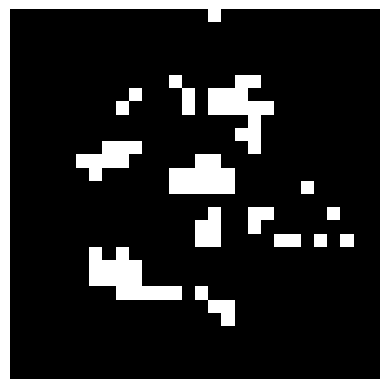

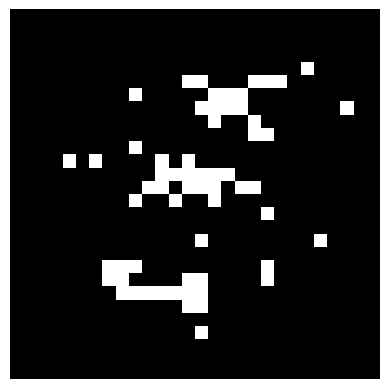

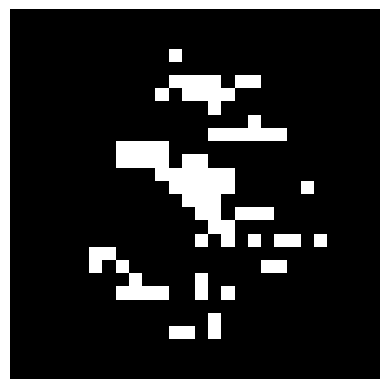

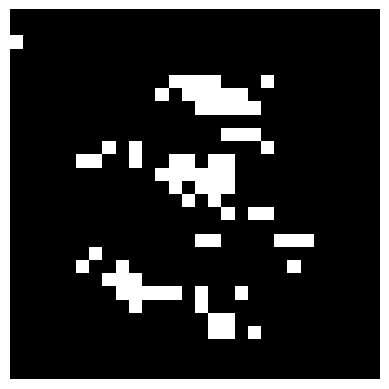

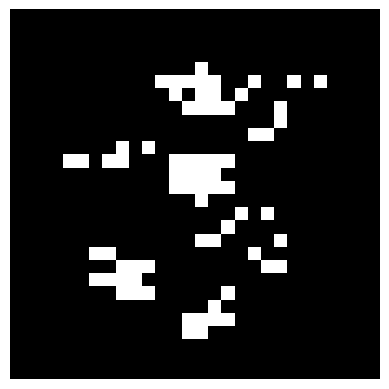

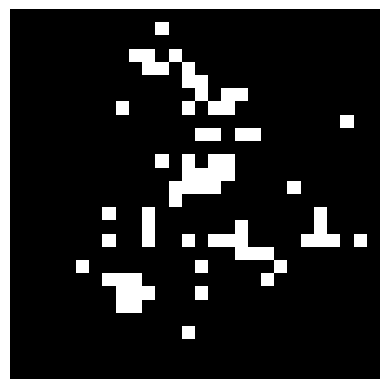

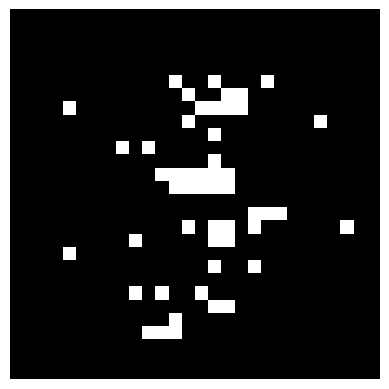

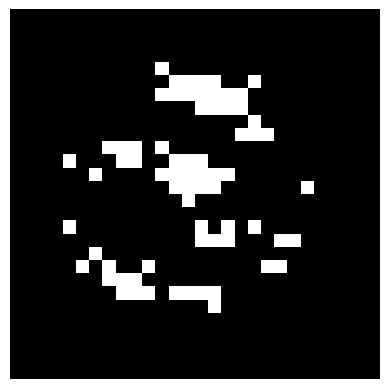

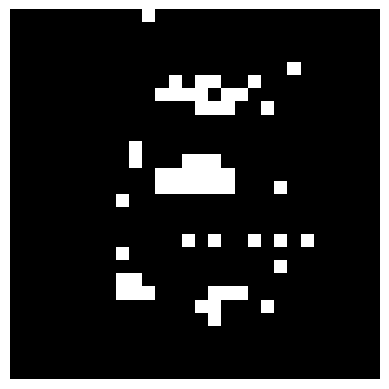

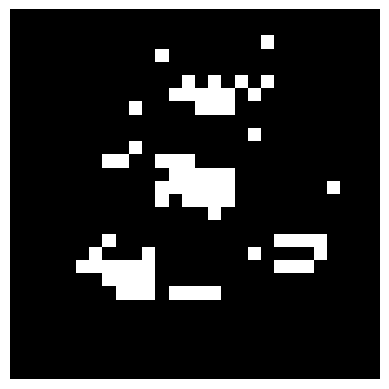

In [8]:
samples = sample(model, 10, input_size)
samples = samples.view(-1, 28, 28).cpu()

for i in range(10):
    plt.imshow(samples[i], cmap="gray")
    plt.axis("off")
    plt.show()